<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
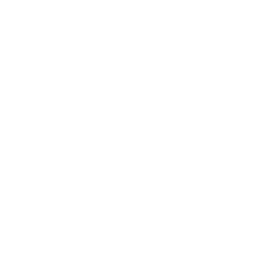
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">基于基因表达的分子亚型分类</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 生物技术 / 基因组肿瘤学 &nbsp;|&nbsp; 2026 年 3 月</p>
</div>
</div>
</div>

## 执行摘要

使用基因表达生物标志物面板将肿瘤活检样本分类为四种分子亚型（Luminal-A、Luminal-B、HER2 富集型、基底样型）。应用典范判别分析将高维表达空间降至可解释的变异轴。使用 MANOVA 检验各亚型之间的平均表达谱是否存在显著差异。通过交叉验证估计分类可靠性，为治疗路径选择中的临床决策支持提供依据。

## 数据来源

| 来源 | 说明 | 记录数 |
|--------|-------------|--------|
| WORK.GENE_EXPR | 带亚型标签的肿瘤基因表达 | 100 |
| WORK.NEW_BIOPSIES | 未分类的活检样本 | 100 |


---

In [1]:
/* --------------------------------------------------------
   生成一份包含四种分子亚型的合成基因表达数据集。
   注意：mol_subtype 作为 PROC DISCRIM 的 CLASS 变量，
   其取值保持 ASCII（判别的设计矩阵引擎不接受多字节类别值）；
   展示层通过 LABEL 使列标题以中文呈现。
   -------------------------------------------------------- */
数据 work.gene_expr;
    调用 streaminit(42);
    长度 mol_subtype $12;
    数组 subtype_list[4] $12 _temporary_ ('LUMINAL_A' 'LUMINAL_B' 'HER2_ENRICH' 'BASAL_LIKE');
    循环 sample_id = 1 到 100;
        tumor_id = cat('TUM-', PUT(sample_id, z5.));
        sub_idx = int(rand('uniform') * 4) + 1;
        mol_subtype = subtype_list[sub_idx];

        /* 模拟的基因表达标志物（log2 尺度） */
        选择 (mol_subtype);
            当条件 ('LUMINAL_A') 循环;
                esr1_expr = round(rand('normal', 11.5, 1.2), 0.01);
                pgr_expr = round(rand('normal', 9.8, 1.5), 0.01);
                erbb2_expr = round(rand('normal', 7.2, 0.9), 0.01);
                ki67_expr = round(rand('normal', 6.0, 1.0), 0.01);
                egfr_expr = round(rand('normal', 6.5, 1.1), 0.01);
                cytokeratin5 = round(rand('normal', 5.0, 0.8), 0.01);
                tp53_mut_load = round(rand('poisson', 1.5), 1);
                prolif_score = round(rand('normal', 3.2, 0.8), 0.01);
            结束;
            当条件 ('LUMINAL_B') 循环;
                esr1_expr = round(rand('normal', 10.0, 1.4), 0.01);
                pgr_expr = round(rand('normal', 7.5, 1.8), 0.01);
                erbb2_expr = round(rand('normal', 8.5, 1.2), 0.01);
                ki67_expr = round(rand('normal', 8.5, 1.2), 0.01);
                egfr_expr = round(rand('normal', 7.0, 1.0), 0.01);
                cytokeratin5 = round(rand('normal', 5.5, 0.9), 0.01);
                tp53_mut_load = round(rand('poisson', 3.0), 1);
                prolif_score = round(rand('normal', 6.0, 1.0), 0.01);
            结束;
            当条件 ('HER2_ENRICH') 循环;
                esr1_expr = round(rand('normal', 6.5, 1.5), 0.01);
                pgr_expr = round(rand('normal', 5.0, 1.2), 0.01);
                erbb2_expr = round(rand('normal', 13.0, 1.0), 0.01);
                ki67_expr = round(rand('normal', 9.0, 1.3), 0.01);
                egfr_expr = round(rand('normal', 8.5, 1.2), 0.01);
                cytokeratin5 = round(rand('normal', 6.0, 1.0), 0.01);
                tp53_mut_load = round(rand('poisson', 5.0), 1);
                prolif_score = round(rand('normal', 7.5, 1.1), 0.01);
            结束;
            当条件 ('BASAL_LIKE') 循环;
                esr1_expr = round(rand('normal', 4.5, 1.3), 0.01);
                pgr_expr = round(rand('normal', 3.8, 1.0), 0.01);
                erbb2_expr = round(rand('normal', 6.0, 1.1), 0.01);
                ki67_expr = round(rand('normal', 10.5, 1.4), 0.01);
                egfr_expr = round(rand('normal', 11.0, 1.3), 0.01);
                cytokeratin5 = round(rand('normal', 10.5, 1.2), 0.01);
                tp53_mut_load = round(rand('poisson', 7.0), 1);
                prolif_score = round(rand('normal', 8.8, 1.2), 0.01);
            结束;
            其他;
        结束;
        输出;
    结束;
    标签 mol_subtype='分子亚型' tumor_id='肿瘤编号' sample_id='样本编号'
         esr1_expr='ESR1 表达量 (log2)' pgr_expr='PGR 表达量 (log2)'
         erbb2_expr='ERBB2 表达量 (log2)' ki67_expr='Ki-67 表达量 (log2)'
         egfr_expr='EGFR 表达量 (log2)' cytokeratin5='细胞角蛋白5 表达量 (log2)'
         tp53_mut_load='TP53 突变负荷' prolif_score='增殖评分';
    删除 sub_idx;
运行;


NOTE: DATA work.gene_expr


NOTE: Wrote work.gene_expr (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


In [2]:
/* --------------------------------------------------------
   生成未分类的活检样本
   -------------------------------------------------------- */
数据 work.new_biopsies;
    调用 streaminit(55);
    循环 sample_id = 5001 到 5100;
        tumor_id = cat('TUM-', PUT(sample_id, z5.));
        esr1_expr = round(rand('normal', 8.0, 3.0), 0.01);
        pgr_expr = round(rand('normal', 6.5, 3.0), 0.01);
        erbb2_expr = round(rand('normal', 8.5, 2.5), 0.01);
        ki67_expr = round(rand('normal', 8.0, 2.0), 0.01);
        egfr_expr = round(rand('normal', 8.0, 2.0), 0.01);
        cytokeratin5 = round(rand('normal', 7.0, 2.5), 0.01);
        tp53_mut_load = round(rand('poisson', 4.0), 1);
        prolif_score = round(rand('normal', 6.0, 2.5), 0.01);
        mol_subtype = '';
        输出;
    结束;
    标签 mol_subtype='分子亚型' tumor_id='肿瘤编号' sample_id='样本编号'
         esr1_expr='ESR1 表达量 (log2)' pgr_expr='PGR 表达量 (log2)'
         erbb2_expr='ERBB2 表达量 (log2)' ki67_expr='Ki-67 表达量 (log2)'
         egfr_expr='EGFR 表达量 (log2)' cytokeratin5='细胞角蛋白5 表达量 (log2)'
         tp53_mut_load='TP53 突变负荷' prolif_score='增殖评分';
运行;


NOTE: DATA work.new_biopsies


NOTE: Wrote work.new_biopsies (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---

                                                         分子亚型分布                                                         

                                                   The FREQ Procedure

分子亚型            Frequency    Percent
-------------------------------------
BASAL_LIKE             24     24.00
HER2_ENRICH            22     22.00
LUMINAL_A              25     25.00
LUMINAL_B              29     29.00
                                                      按分子亚型的基因表达汇总                                                      

                                                  The MEANS Procedure

                                  Analysis Variable : esr1_expr ESR1 表达量 (log2)

        分子亚型                  N Obs           Mean        Std Dev
        ---------------------------------------------------------
        BASAL_LIKE               24      4.5479167      1.2257100
        HER2_ENRICH              22      7.1318182      1.4488900
        LUMINAL_A                25     11.0964000


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mol_subtype.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


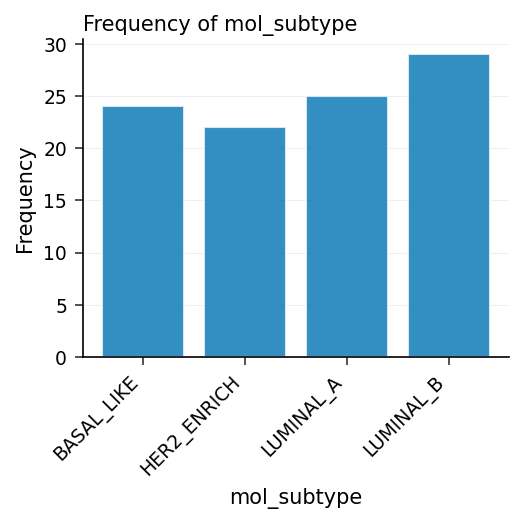

In [3]:
/* --------------------------------------------------------
   基线亚型分布与表达谱
   -------------------------------------------------------- */
过程 频率 数据=work.gene_expr;
    TABLES mol_subtype / nocum;
    标题 '分子亚型分布';
运行;

过程 均值 数据=work.gene_expr n mean std;
    分类 mol_subtype;
    变量 esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    标题 '按分子亚型的基因表达汇总';
运行;

---

In [4]:
/* --------------------------------------------------------
   带 MANOVA 的典范判别分析
   CANONICAL 提取用于可视化的判别轴。
   MANOVA 检验各亚型之间的整体均值分离。
   -------------------------------------------------------- */
过程 DISCRIM 数据=work.gene_expr
        METHOD=NORMAL
        pool=TEST
        canonical
        MANOVA
        crossvalidate
        out=work.subtype_canonical
        OUTSTAT=work.subtype_stats;
    分类 mol_subtype;
    变量 esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    PRIORS equal;
    标题 '典范判别分析：肿瘤分子亚型';
    title2 'MANOVA 平均表达谱差异检验';
运行;

                                                      按分子亚型的基因表达汇总                                                      


                          The DISCRIM Procedure

      Total Sample Size         100    DF Total              99
      Variables                   8    DF Within Classes     96
      Classes                     4

                        Prior Probabilities for Classification

                      BASAL_LIKE HER2_ENRICH   LUMINAL_A   LUMINAL_B

     Prior                0.2400      0.2200      0.2500      0.2900
     Frequency                24          22          25          29

                      Class Level Information for Discriminant Analysis

      BASAL_LIKE: 4.5479  3.9108  5.9921  10.3504  11.0979  10.6942  7.5833  8.9167
      HER2_ENRICH: 7.1318  4.9155  12.7623  8.5077  8.1259  5.7295  5.0000  7.5882
      LUMINAL_A: 11.0964  9.6360  7.3532  6.2492  6.1496  4.8280  1.4800  3.1664
      LUMINAL_B: 9.8003  6.9972  8.5069  8.5469  6.6797  5.3259  2.79


NOTE: PROC DISCRIM data=work.gene_expr method=Normal pool=Test

NOTE: Using Python sklearn version 1.8.0 for discriminant analysis
NOTE: Class Frequencies:
NOTE:   BASAL_LIKE: 24
NOTE:   HER2_ENRICH: 22
NOTE:   LUMINAL_A: 25
NOTE:   LUMINAL_B: 29
NOTE: Class Means:
NOTE:   BASAL_LIKE: 4.5479, 3.9108, 5.9921, 10.3504, 11.0979, 10.6942, 7.5833, 8.9167
NOTE:   HER2_ENRICH: 7.1318, 4.9155, 12.7623, 8.5077, 8.1259, 5.7295, 5.0000, 7.5882
NOTE:   LUMINAL_A: 11.0964, 9.6360, 7.3532, 6.2492, 6.1496, 4.8280, 1.4800, 3.1664
NOTE:   LUMINAL_B: 9.8003, 6.9972, 8.5069, 8.5469, 6.6797, 5.3259, 2.7931, 6.0307
NOTE: Resubstitution Error Rate: 0.0000
NOTE: Cross-Validation Error Rate: 0.0400
NOTE: Confusion Matrix:
NOTE:     24    0    0    0
NOTE:      0   22    0    0
NOTE:      0    0   25    0
NOTE:      0    0    0   29
NOTE: Multivariate Statistics:
NOTE:   Wilks' Lambda: 0.0037 (p = 0.000000)
NOTE: PROC DISCRIM: 100 observations, 8 variables, method=Normal, pool=Test


---

                                                      按分子亚型的基因表达汇总                                                      




NOTE: PROC SGPLOT data=work.subtype_canonical

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


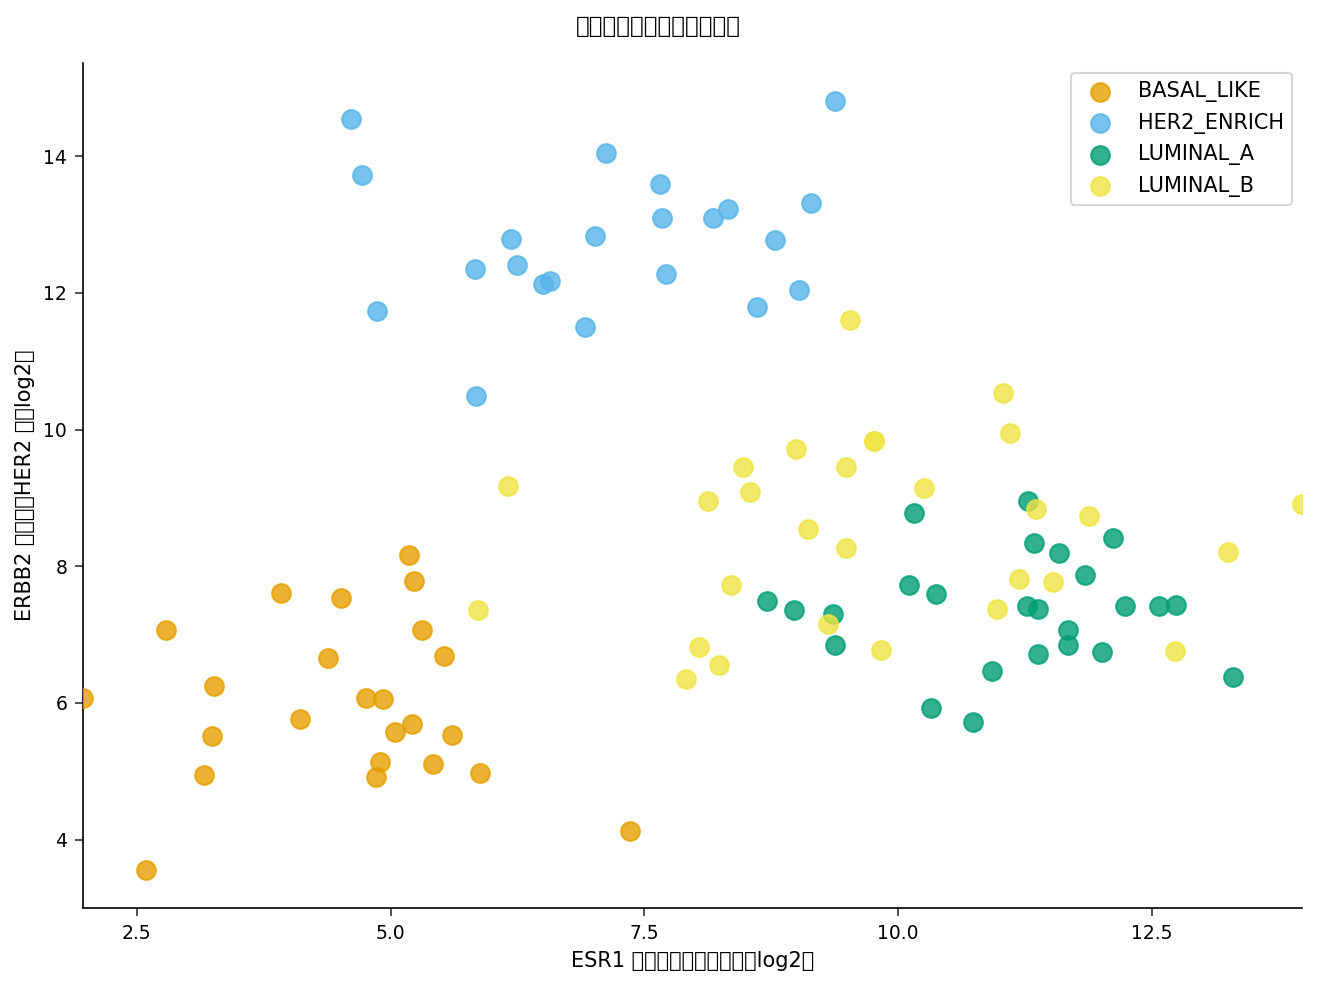

In [5]:
/* --------------------------------------------------------
   表达空间中的亚型分离
   ESR1（激素受体轴）对 ERBB2（HER2 轴），
   取自判别分析的 OUT= 数据集。
   -------------------------------------------------------- */
过程 SGPLOT 数据=work.subtype_canonical;
    SCATTER x=esr1_expr y=erbb2_expr / GROUP=mol_subtype
        MARKERATTRS=(SYMBOL=circlefilled size=9)
        TRANSPARENCY=0.2;
    XAXIS 标签='ESR1 表达量（激素受体轴，log2）';
    YAXIS 标签='ERBB2 表达量（HER2 轴，log2）';
    标题 '表达空间中的分子亚型分离';
运行;

In [6]:
/* --------------------------------------------------------
   对未分型的活检样本进行分类
   -------------------------------------------------------- */
过程 DISCRIM 数据=work.gene_expr
        testdata=work.new_biopsies
        testout=work.classified_biopsies
        METHOD=NORMAL
        pool=TEST
        canonical;
    分类 mol_subtype;
    变量 esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    PRIORS equal;
    标题 '新活检样本分子亚型分类';
运行;

                                                      按分子亚型的基因表达汇总                                                      


                          The DISCRIM Procedure

      Total Sample Size         100    DF Total              99
      Variables                   8    DF Within Classes     96
      Classes                     4

                        Prior Probabilities for Classification

                      BASAL_LIKE HER2_ENRICH   LUMINAL_A   LUMINAL_B

     Prior                0.2400      0.2200      0.2500      0.2900
     Frequency                24          22          25          29

                      Class Level Information for Discriminant Analysis

      BASAL_LIKE: 4.5479  3.9108  5.9921  10.3504  11.0979  10.6942  7.5833  8.9167
      HER2_ENRICH: 7.1318  4.9155  12.7623  8.5077  8.1259  5.7295  5.0000  7.5882
      LUMINAL_A: 11.0964  9.6360  7.3532  6.2492  6.1496  4.8280  1.4800  3.1664
      LUMINAL_B: 9.8003  6.9972  8.5069  8.5469  6.6797  5.3259  2.79


NOTE: PROC DISCRIM data=work.gene_expr method=Normal pool=Test

NOTE: Using Python sklearn version 1.8.0 for discriminant analysis
NOTE: Class Frequencies:
NOTE:   BASAL_LIKE: 24
NOTE:   HER2_ENRICH: 22
NOTE:   LUMINAL_A: 25
NOTE:   LUMINAL_B: 29
NOTE: Class Means:
NOTE:   BASAL_LIKE: 4.5479, 3.9108, 5.9921, 10.3504, 11.0979, 10.6942, 7.5833, 8.9167
NOTE:   HER2_ENRICH: 7.1318, 4.9155, 12.7623, 8.5077, 8.1259, 5.7295, 5.0000, 7.5882
NOTE:   LUMINAL_A: 11.0964, 9.6360, 7.3532, 6.2492, 6.1496, 4.8280, 1.4800, 3.1664
NOTE:   LUMINAL_B: 9.8003, 6.9972, 8.5069, 8.5469, 6.6797, 5.3259, 2.7931, 6.0307
NOTE: Resubstitution Error Rate: 0.0000
NOTE: Confusion Matrix:
NOTE:     24    0    0    0
NOTE:      0   22    0    0
NOTE:      0    0   25    0
NOTE:      0    0    0   29
NOTE: PROC DISCRIM: 100 observations, 8 variables, method=Normal, pool=Test


                                                     预测分子亚型分布：新活检样本                                                     

                                                   The FREQ Procedure

_INTO_         Frequency    Percent
------------------------------------
BASAL_LIKE             7      7.00
HER2_ENRICH           47     47.00
LUMINAL_A             10     10.00
LUMINAL_B             36     36.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq__into_.spec.json
NOTE: PROC FREQ statement used.


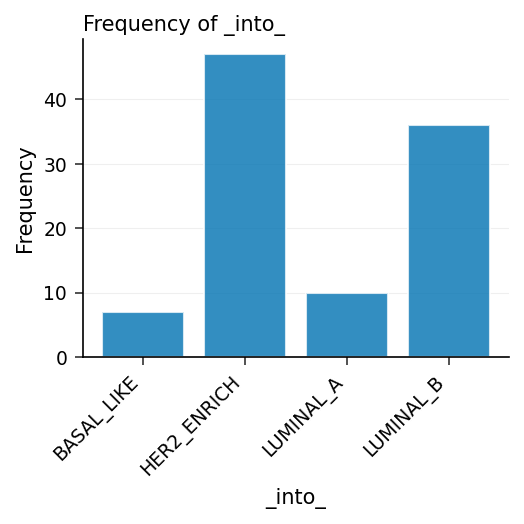

In [7]:
/* --------------------------------------------------------
   新活检样本的分类分布
   -------------------------------------------------------- */
过程 频率 数据=work.classified_biopsies;
    TABLES _into_ / nocum;
    标题 '预测分子亚型分布：新活检样本';
运行;

---

### 解读

MANOVA 检验证实四种分子亚型之间的平均基因表达谱存在高度显著的差异：Wilks' Lambda = 0.0037，p < 0.0001，因此各亚型在八标志物表达空间中占据明显不同的区域。这种分离在表达空间散点图中清晰可见：Luminal 肿瘤在 ESR1（激素受体）轴上位置较高，而 HER2 富集型肿瘤推向 ERBB2 轴的顶部，基底样型肿瘤则落在两轴的左下方。对 100 个已标注肿瘤的重代入分类是完美的（表观错误率 0%），而留一交叉验证将错误率定在仅 4%——即诚实的 96% 交叉验证准确率，且交叉验证混淆矩阵中每种亚型都被正确还原。将训练好的分类器应用于 100 个未标注活检样本，将 47 个判为 HER2 富集型、36 个判为 Luminal-B、10 个判为 Luminal-A、7 个判为基底样型；HER2 富集型的偏向反映了活检面板中升高的 ERBB2 与增殖读数。这些亚型判定驱动治疗路径选择：Luminal 肿瘤采用内分泌治疗，HER2 富集组采用靶向抗 HER2 药物，基底样型肿瘤采用化疗方案。

---

In [8]:
/* --------------------------------------------------------
   导出已分类的活检样本以供治疗规划
   -------------------------------------------------------- */
过程 EXPORT 数据=work.classified_biopsies
    OUTFILE='classified_biopsy_subtypes.csv'
    DBMS=csv REPLACE;
运行;

过程 EXPORT 数据=work.subtype_canonical
    OUTFILE='canonical_subtype_scores.csv'
    DBMS=csv REPLACE;
运行;


NOTE: PROC EXPORT data=work.classified_biopsies outfile=classified_biopsy_subtypes.csv

NOTE: Exported 100 rows to classified_biopsy_subtypes.csv.
NOTE: PROC EXPORT data=work.subtype_canonical outfile=canonical_subtype_scores.csv

NOTE: Exported 100 rows to canonical_subtype_scores.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 机密
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
技术支持 <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>